Tóm tắt:
- a) b) c) d) ok rùi
- Markdown đang note idea với cho chat gen markdown để tạo bố cục bài, chưa viết kĩ
- câu e) đang tìm hiểu thêm
- code phần visualize là gen ra tại vẽ biểu đồ lu bu quá vẽ 6

# Part 4: Preprocessing Temporal Data - Stock Market Dataset

---
## Mô tả Dataset: Stock Market Data

### 1. Nguồn dữ liệu
- **Dataset**: Stock Market Data (NASDAQ, NYSE, S&P500)
- **Link Kaggle**: https://www.kaggle.com/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs

### 2. Cấu trúc thư mục
```
data/temporal/stock_market_data/
├── forbes2000/    (2246 files)
├── nasdaq/        (3617 files)
├── nyse/          (2516 files)
└── sp500/         (831 files)
    ├── csv/       (409 file CSV)
    └── json/      (422 file JSON)
```
**Tổng cộng**: ~9210 files cho các cổ phiếu từ 4 sàn giao dịch lớn của Mỹ.

### 3. Cấu trúc file CSV
Mỗi file CSV chứa dữ liệu lịch sử của một mã cổ phiếu với các cột:

| Cột | Kiểu dữ liệu | Mô tả |
|-----|--------------|-------|
| **Date** | String (DD-MM-YYYY) | Ngày giao dịch |
| **Open** | Float | Giá mở cửa |
| **High** | Float | Giá cao nhất trong ngày |
| **Low** | Float | Giá thấp nhất trong ngày |
| **Close** | Float | Giá đóng cửa |
| **Volume** | Integer | Khối lượng giao dịch |
| **Adjusted Close** | Float | Giá đóng cửa đã điều chỉnh (tính cả chia cổ tức, stock split) |

### 4. Lý do chọn mã cổ phiếu Apple (AAPL)

Chúng tôi chọn **Apple Inc. (AAPL)** vì các lý do sau:

1. **Dữ liệu phong phú**: AAPL có lịch sử giao dịch từ năm 1980 đến nay (~44 năm), cung cấp đủ dữ liệu để phân tích xu hướng dài hạn.

2. **Tính thanh khoản cao**: Apple là một trong những cổ phiếu được giao dịch nhiều nhất trên thị trường, đảm bảo dữ liệu liên tục và đáng tin cậy.

3. **Đại diện cho thị trường**: AAPL là thành phần của cả 3 chỉ số chính:
   - S&P 500
   - NASDAQ Composite
   - Dow Jones Industrial Average

4. **Nhiều sự kiện thú vị**: Lịch sử giá AAPL bao gồm nhiều sự kiện quan trọng như:
   - Stock splits (chia tách cổ phiếu)
   - Các đợt tăng/giảm giá mạnh
   - Khủng hoảng tài chính 2008, COVID-19 2020

5. **File size phù hợp**: ~10,590 records (~1.2 MB) - đủ lớn để thể hiện các kỹ thuật preprocessing nhưng không quá nặng để xử lý.

### 5. Đặc điểm dữ liệu chuỗi thời gian
- **Tần suất**: Dữ liệu hàng ngày (daily)
- **Khoảng trống tự nhiên**: Cuối tuần và ngày lễ không có giao dịch
- **Tính chu kỳ**: Có patterns theo ngày trong tuần, tháng, quý
- **Xu hướng**: Có xu hướng tăng dài hạn


## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

## Load Data
Chúng ta sẽ sử dụng dữ liệu cổ phiếu Apple (AAPL) từ S&P 500 - một trong những cổ phiếu được giao dịch nhiều nhất.

In [ ]:
df = pd.read_csv('../data/temporal/stock_market_data/sp500/csv/AAPL.csv')

Số dòng: 10590
Số cột: 7

Các cột: ['Date', 'Low', 'Open', 'Volume', 'High', 'Close', 'Adjusted Close']


,Date,Low,Open,Volume,High,Close,Adjusted Close
0,12-12-1980,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1,15-12-1980,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
2,16-12-1980,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
3,17-12-1980,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
4,18-12-1980,0.118862,0.118862,73449600,0.119420,0.118862,0.092492
5,19-12-1980,0.126116,0.126116,48630400,0.126674,0.126116,0.098137
6,22-12-1980,0.132254,0.132254,37363200,0.132813,0.132254,0.102913
7,23-12-1980,0.137835,0.137835,46950400,0.138393,0.137835,0.107256
8,24-12-1980,0.145089,0.145089,48003200,0.145647,0.145089,0.112901
9,26-12-1980,0.158482,0.158482,55574400,0.159040,0.158482,0.123322


Thông tin tổng quan dữ liệu

In [ ]:
print(f"Số dòng: {len(df)}")
print(f"Số cột: {len(df.columns)}")
print(f"\nCác cột: {df.columns.tolist()}")
df.head(10)

Thông tin các thuộc tính

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10590 entries, 0 to 10589
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            10590 non-null  object 
 1   Low             10590 non-null  float64
 2   Open            10590 non-null  float64
 3   Volume          10590 non-null  int64  
 4   High            10590 non-null  float64
 5   Close           10590 non-null  float64
 6   Adjusted Close  10590 non-null  float64
dtypes: float64(5), int64(1), object(1)
memory usage: 579.3+ KB


---
# a) Parsing Date and Time

## Lý do cần thiết
- Cột Date hiện đang ở dạng string, cần chuyển sang datetime để thực hiện các phép tính thời gian
- Việc parse datetime cho phép trích xuất các thành phần như năm, tháng, ngày
- Cần thiết lập datetime index để sử dụng các tính năng time series của pandas

### Đầu tiên, chúng ta sẽ tiến hành kiểm tra dữ liệu và kiểu dữ liệu hiện tại của biến thời gian 

In [ ]:
print("Kiểu dữ liệu cột Date:", df['Date'].dtype)
print("\nMẫu dữ liệu Date:")
print(df['Date'].head(10))

Kiểu dữ liệu cột Date: object

Mẫu dữ liệu Date:
0    12-12-1980
1    15-12-1980
2    16-12-1980
3    17-12-1980
4    18-12-1980
5    19-12-1980
6    22-12-1980
7    23-12-1980
8    24-12-1980
9    26-12-1980
Name: Date, dtype: object


### Dữ liệu đang ở kiểu **object** với cấu trúc DD-MM-YYYY. Bây giờ ta sẽ tiến hành parse dữ liệu này thành datetime object.

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
print("Kiểu dữ liệu sau khi parse:", df['Date'].dtype)
print("\nMẫu dữ liệu:")
df.head()

Kiểu dữ liệu sau khi parse: datetime64[ns]

Mẫu dữ liệu:


,Date,Low,Open,Volume,High,Close,Adjusted Close
0,1980-12-12,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1,1980-12-15,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
2,1980-12-16,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
3,1980-12-17,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
4,1980-12-18,0.118862,0.118862,73449600,0.119420,0.118862,0.092492


Do 1 lát nữa sẽ dùng các dữ liệu này cho phần (c), (d), (e) nên giờ sẽ extract thành phần của datetime và tách thành các cột riêng

In [ ]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['DayName'] = df['Date'].dt.day_name()
df['Quarter'] = df['Date'].dt.quarter
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

print("Các thành phần thời gian đã trích xuất:")
df[['Date', 'Year', 'Month', 'Day', 'DayOfWeek', 'DayName', 'Quarter', 'WeekOfYear']].head(10)

Các thành phần thời gian đã trích xuất:


,Date,Year,Month,Day,DayOfWeek,DayName,Quarter,WeekOfYear
0,1980-12-12,1980,12,12,4,Friday,4,50
1,1980-12-15,1980,12,15,0,Monday,4,51
2,1980-12-16,1980,12,16,1,Tuesday,4,51
3,1980-12-17,1980,12,17,2,Wednesday,4,51
4,1980-12-18,1980,12,18,3,Thursday,4,51
5,1980-12-19,1980,12,19,4,Friday,4,51
6,1980-12-22,1980,12,22,0,Monday,4,52
7,1980-12-23,1980,12,23,1,Tuesday,4,52
8,1980-12-24,1980,12,24,2,Wednesday,4,52
9,1980-12-26,1980,12,26,4,Friday,4,52


Xử lý xong kiểu dữ liệu rồi bây giờ chúng ta sẽ dựng trục thời gian cho dữ liệu (dùng pandas datetime index cho Date)

In [ ]:
df_indexed = df.set_index('Date').sort_index()
print(f"Phạm vi thời gian: {df_indexed.index.min()} đến {df_indexed.index.max()}")
print(f"Tổng thời gian: {(df_indexed.index.max() - df_indexed.index.min()).days} ngày")
df_indexed.head()

Phạm vi thời gian: 1980-12-12 00:00:00 đến 2022-12-12 00:00:00
Tổng thời gian: 15340 ngày


,Low,Open,Volume,High,Close,Adjusted Close,Year,Month,Day,DayOfWeek,DayName,Quarter,WeekOfYear
Date,,,,,,,,,,,,,
1980-12-12,0.128348,0.128348,469033600,0.128906,0.128348,0.099874,1980,12,12,4,Friday,4,50
1980-12-15,0.121652,0.122210,175884800,0.122210,0.121652,0.094663,1980,12,15,0,Monday,4,51
1980-12-16,0.112723,0.113281,105728000,0.113281,0.112723,0.087715,1980,12,16,1,Tuesday,4,51
1980-12-17,0.115513,0.115513,86441600,0.116071,0.115513,0.089886,1980,12,17,2,Wednesday,4,51
1980-12-18,0.118862,0.118862,73449600,0.119420,0.118862,0.092492,1980,12,18,3,Thursday,4,51


Để có thể quan sát xu hướng dữ liệu time series sau khi format về Datetime object, em sẽ dùng line chart cho giá chốt (Close price) để visualize

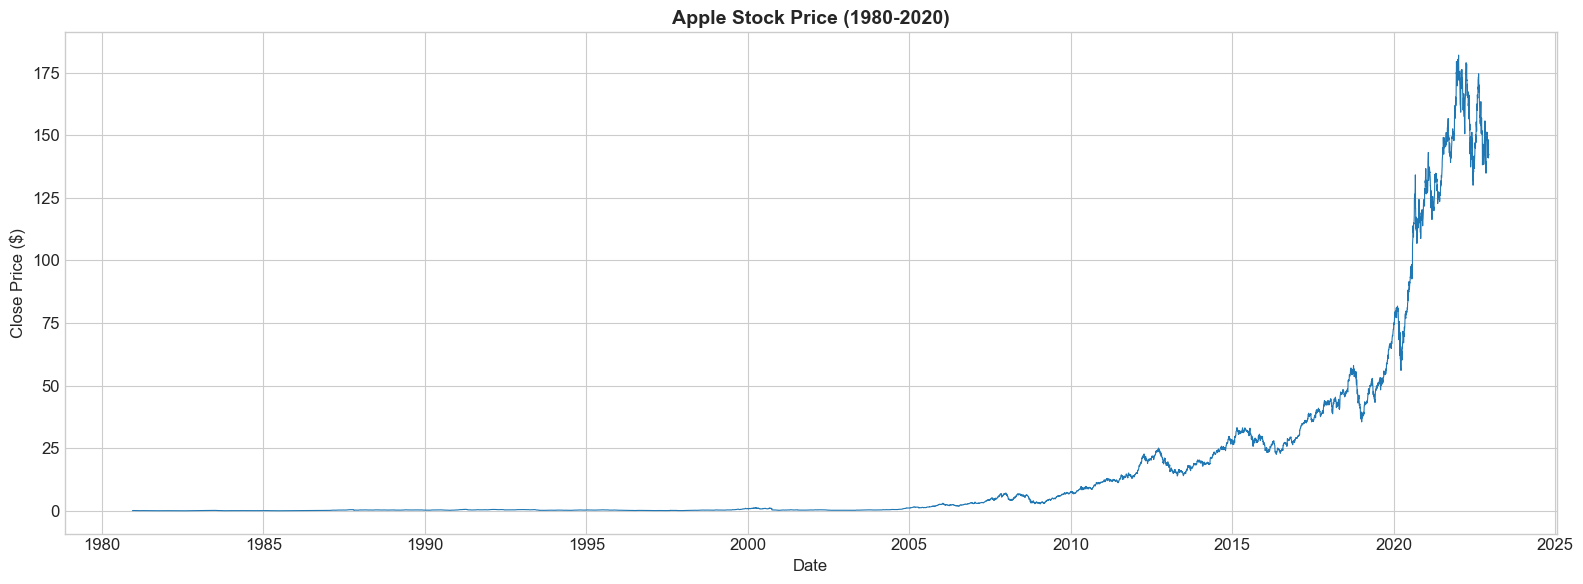

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df_indexed.index, df_indexed['Close'], linewidth=0.8)
ax.set_title('Apple Stock Price (1980-2020)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price ($)')
plt.tight_layout()
plt.show()

**Nhận xét:**
- Dữ liệu đã được parse thành công từ string sang datetime
- Phạm vi thời gian từ 1980 đến hiện tại (~44 năm dữ liệu)
- Các thành phần thời gian (năm, tháng, ngày, quý) đã được trích xuất thành công

---
# b) Handling Time Gaps

## Lý do cần thiết
- Thị trường chứng khoán đóng cửa vào cuối tuần và ngày lễ, tạo ra các khoảng trống thời gian
- Một số ngày có thể thiếu dữ liệu do lỗi hệ thống
- Cần xác định và xử lý các khoảng trống này để phân tích chính xác

Dựa trên datetime index đã thiết lập ở (a). Chúng ta sẽ tìm những time gaps trong dữ liệu

In [ ]:
df_sorted = df.sort_values('Date').reset_index(drop=True)
df_sorted['TimeDiff'] = df_sorted['Date'].diff()

Do dữ liệu là ở cấp ngày (mỗi datapoint cách nhau 1 ngày), nên để tìm time gaps em sẽ tìm những datapoint cách nhau nhiều hơn 1 ngày

In [ ]:
gaps = df_sorted[df_sorted['TimeDiff'] > pd.Timedelta(days=1)]
print(f"Số khoảng trống > 1 ngày: {len(gaps)}")
print(f"\nPhân bố khoảng trống:")
print(gaps['TimeDiff'].value_counts().head(10))

Số khoảng trống > 1 ngày: 2289

Phân bố khoảng trống:
TimeDiff
3 days    1927
4 days     262
2 days      97
5 days       2
7 days       1
Name: count, dtype: int64


Mình đã có số liệu về những time gaps đang có của mã cổ phiếu. Bây giờ em sẽ visualize nó lên để có cái nhìn trực quan hơn

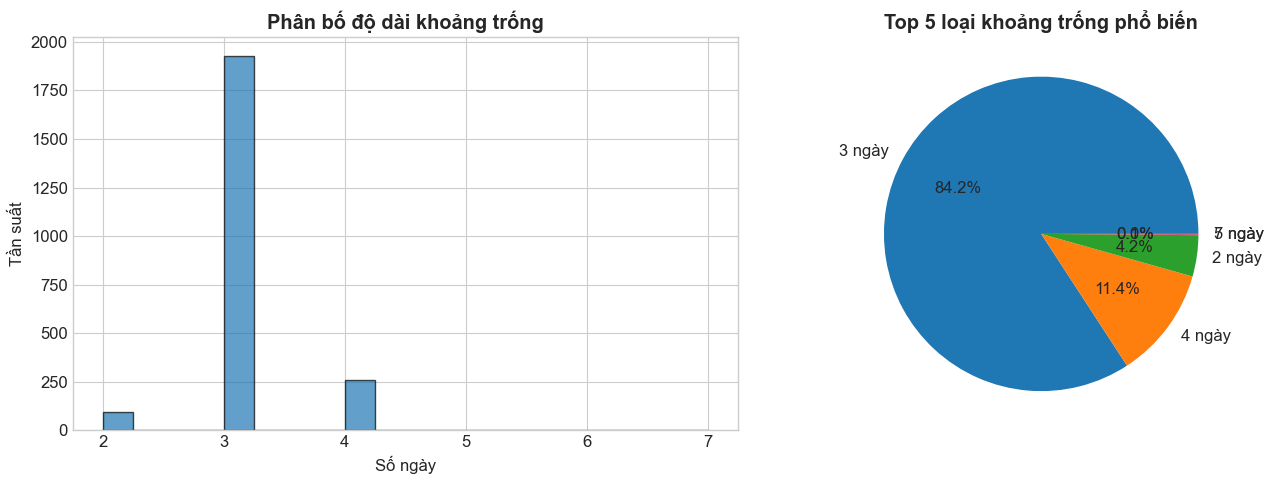

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
gap_days = gaps['TimeDiff'].dt.days
axes[0].hist(gap_days, bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title('Phân bố độ dài khoảng trống', fontweight='bold')
axes[0].set_xlabel('Số ngày')
axes[0].set_ylabel('Tần suất')

# Pie chart
gap_counts = gap_days.value_counts().head(5)
axes[1].pie(gap_counts.values, labels=[f'{d} ngày' for d in gap_counts.index], autopct='%1.1f%%')
axes[1].set_title('Top 5 loại khoảng trống phổ biến', fontweight='bold')

plt.tight_layout()
plt.show()

Bây giờ em sẽ tạo chuỗi thời gian thực và đối chiếu với dữ liệu xem chúng ta bị thiếu bao nhiêu ngày

In [ ]:
date_range = pd.date_range(start=df_indexed.index.min(), end=df_indexed.index.max(), freq='D')
df_complete = df_indexed.reindex(date_range)

print(f"Số dòng ban đầu: {len(df_indexed)}")
print(f"Số dòng sau khi reindex: {len(df_complete)}")
print(f"Số ngày thiếu dữ liệu: {df_complete['Close'].isna().sum()}")

Số dòng ban đầu: 10590
Số dòng sau khi reindex: 15341
Số ngày thiếu dữ liệu: 4751


Mình có 5 kĩ thuật cần triển khai và so sánh, Cụ thể là:

1. Fill
- Forward Fill
- Backward Fill
2. Interpolate
- Linear
- Polynomial
- Spline


In [ ]:
# 1. Forward Fill
df_ffill = df_complete['Close'].ffill()

# 2. Backward Fill
df_bfill = df_complete['Close'].bfill()

# 3. Linear Interpolation
df_linear = df_complete['Close'].interpolate(method='linear')

# 4. Polynomial Interpolation (order=2)
df_poly = df_complete['Close'].interpolate(method='polynomial', order=2)

# 5. Spline Interpolation (order=3 - cubic spline)
df_spline = df_complete['Close'].interpolate(method='spline', order=3)

Đã áp dụng 5 phương pháp xử lý khoảng trống:
1. Forward Fill (ffill)
2. Backward Fill (bfill)
3. Linear Interpolation
4. Polynomial Interpolation (order=2)
5. Spline Interpolation (order=3)


Bây giờ em sẽ lấy 1 khoảng có gap để visualize lên so sánh 5 phương pháp handling time gaps này

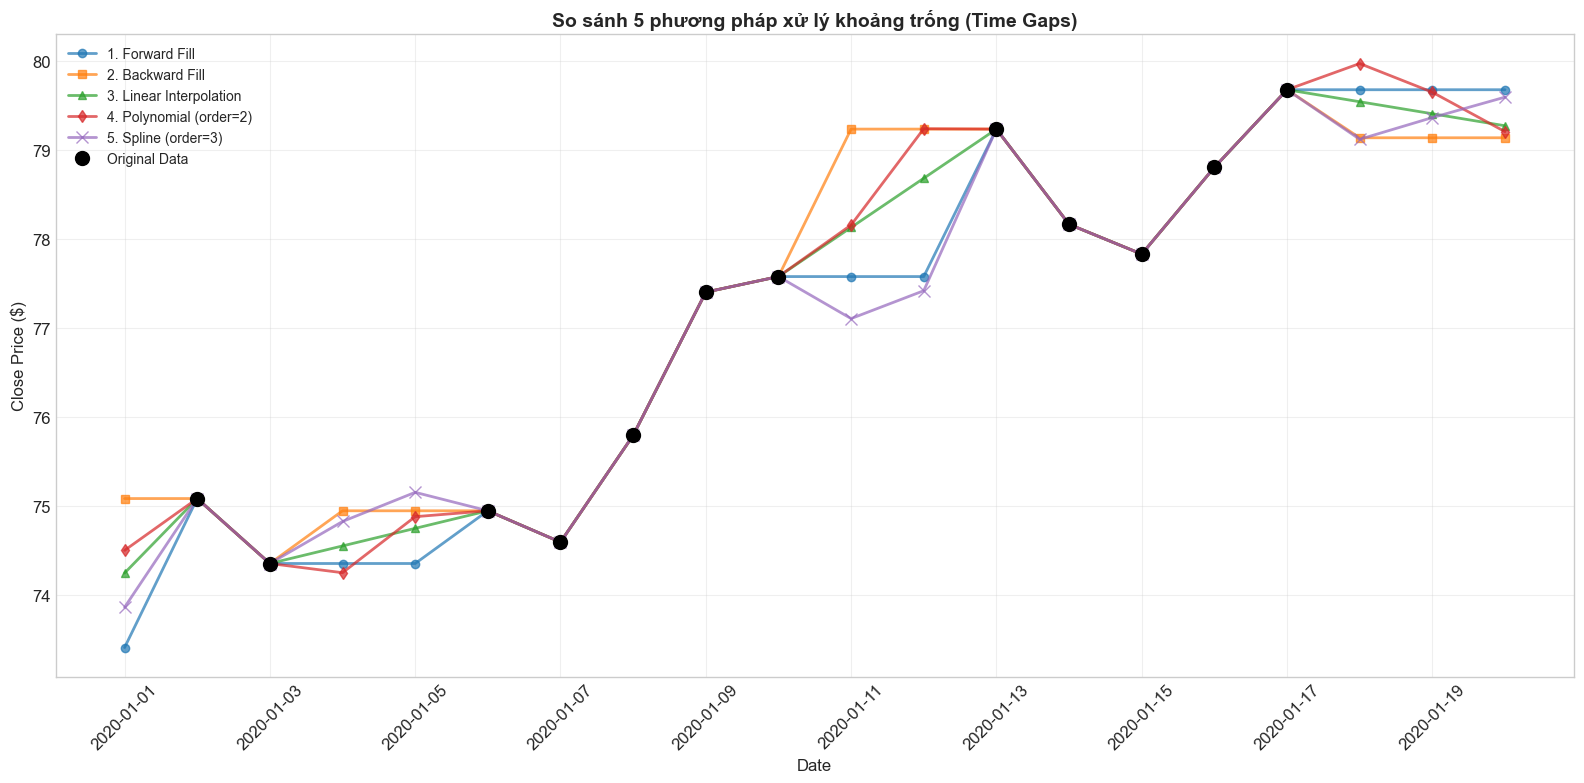

In [ ]:
sample_start = '2020-01-01'
sample_end = '2020-01-20'

fig, ax = plt.subplots(figsize=(16, 8))

# Plot all 5 methods
ax.plot(df_ffill[sample_start:sample_end], 'o-', label='1. Forward Fill', alpha=0.7, markersize=6, linewidth=2)
ax.plot(df_bfill[sample_start:sample_end], 's-', label='2. Backward Fill', alpha=0.7, markersize=6, linewidth=2)
ax.plot(df_linear[sample_start:sample_end], '^-', label='3. Linear Interpolation', alpha=0.7, markersize=6, linewidth=2)
ax.plot(df_poly[sample_start:sample_end], 'd-', label='4. Polynomial (order=2)', alpha=0.7, markersize=6, linewidth=2)
ax.plot(df_spline[sample_start:sample_end], 'x-', label='5. Spline (order=3)', alpha=0.7, markersize=8, linewidth=2)

# Plot original data points
original = df_complete['Close'][sample_start:sample_end]
ax.plot(original.dropna(), 'ko', label='Original Data', markersize=10, zorder=5)

ax.set_title('So sánh 5 phương pháp xử lý khoảng trống (Time Gaps)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Close Price ($)', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Biểu đồ chi tiết cho từng phương pháp

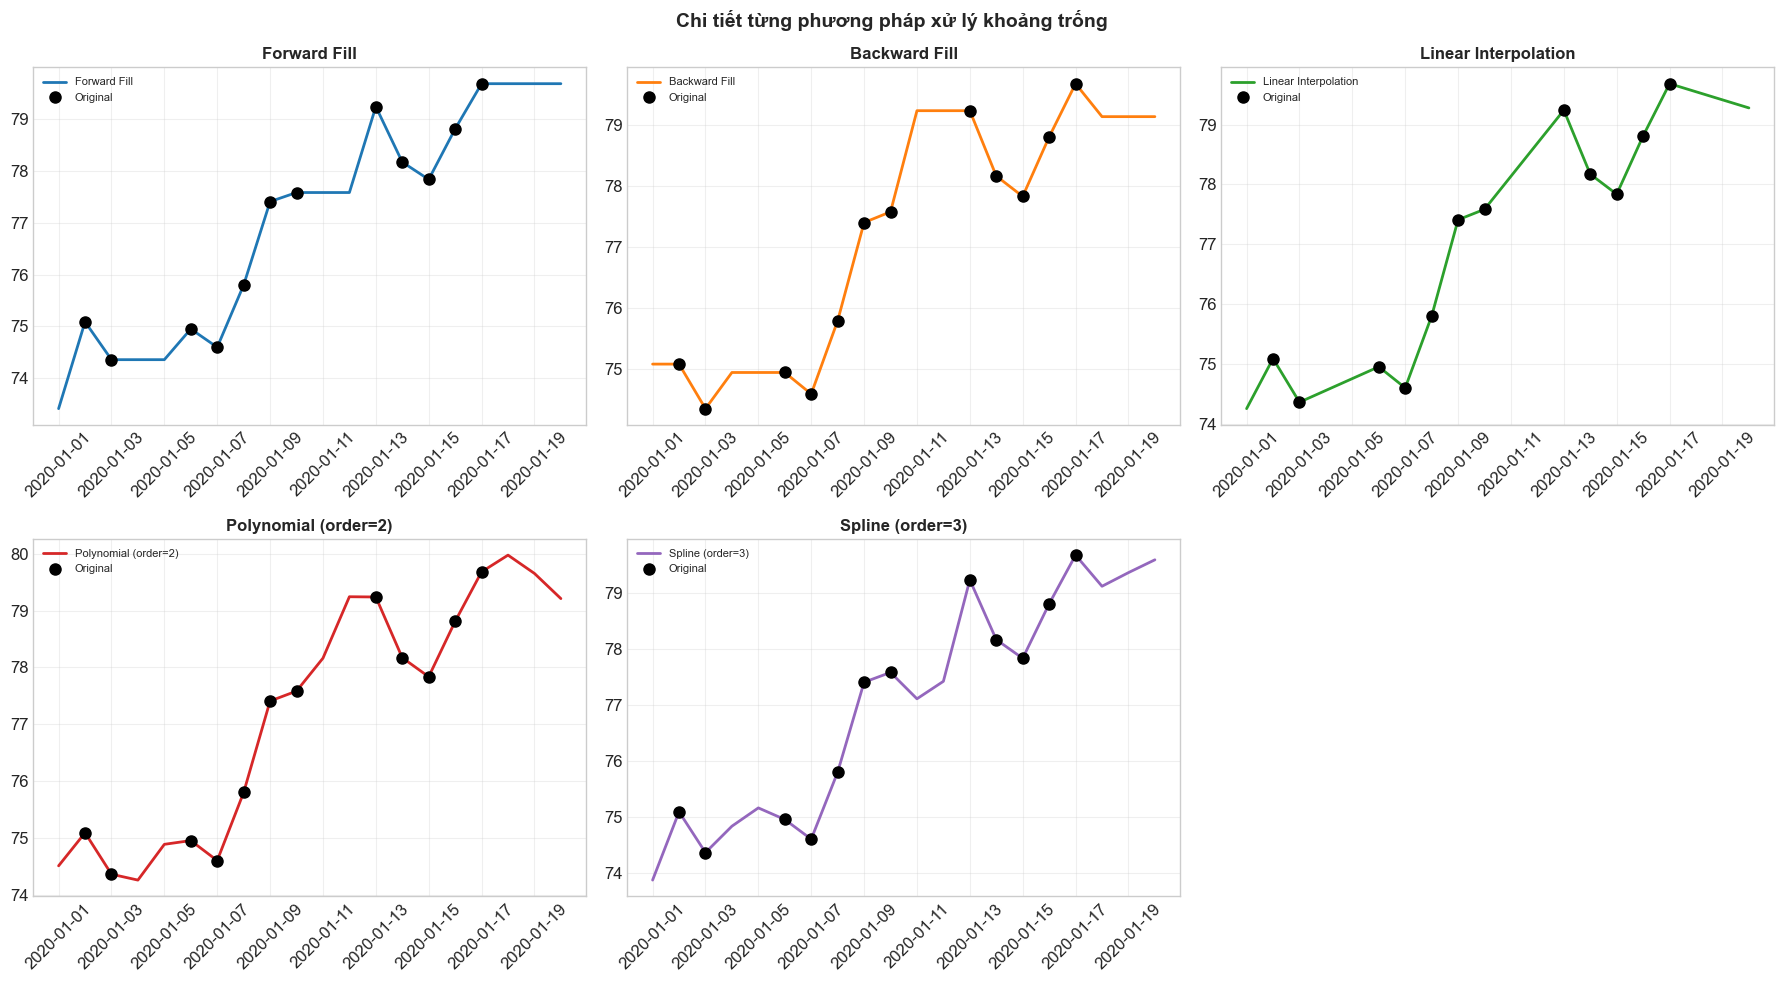

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sample_start = '2020-01-01'
sample_end = '2020-01-20'

original = df_complete['Close'][sample_start:sample_end]

methods = [
    ('Forward Fill', df_ffill[sample_start:sample_end], 'tab:blue'),
    ('Backward Fill', df_bfill[sample_start:sample_end], 'tab:orange'),
    ('Linear Interpolation', df_linear[sample_start:sample_end], 'tab:green'),
    ('Polynomial (order=2)', df_poly[sample_start:sample_end], 'tab:red'),
    ('Spline (order=3)', df_spline[sample_start:sample_end], 'tab:purple'),
]

for idx, (name, data, color) in enumerate(methods):
    row, col = idx // 3, idx % 3
    ax = axes[row, col]
    ax.plot(data.index, data.values, '-', color=color, linewidth=2, label=name)
    ax.plot(original.dropna().index, original.dropna().values, 'ko', markersize=8, label='Original')
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide last empty subplot
axes[1, 2].axis('off')

plt.suptitle('Chi tiết từng phương pháp xử lý khoảng trống', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Ngoài phụ thuộc vào phương pháp, kết quả handling time gaps còn phụ thuộc vào định lượng sử dụng để interpolate. Đây là bảng so sánh chi tiết

In [15]:
# Phân tích định lượng các phương pháp
# Tính toán các chỉ số so sánh

# Lấy index các điểm có dữ liệu thực
original_data = df_complete['Close'].dropna()

# Tạo bảng so sánh
comparison_data = {
    'Method': ['Forward Fill', 'Backward Fill', 'Linear', 'Polynomial', 'Spline'],
    'Mean': [
        df_ffill.mean(),
        df_bfill.mean(),
        df_linear.mean(),
        df_poly.mean(),
        df_spline.mean()
    ],
    'Std': [
        df_ffill.std(),
        df_bfill.std(),
        df_linear.std(),
        df_poly.std(),
        df_spline.std()
    ],
    'Min': [
        df_ffill.min(),
        df_bfill.min(),
        df_linear.min(),
        df_poly.min(),
        df_spline.min()
    ],
    'Max': [
        df_ffill.max(),
        df_bfill.max(),
        df_linear.max(),
        df_poly.max(),
        df_spline.max()
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print('Bảng so sánh các phương pháp xử lý khoảng trống:')
df_comparison

Bảng so sánh các phương pháp xử lý khoảng trống:


,Method,Mean,Std,Min,Max
0,Forward Fill,16.334488,34.908478,0.049107,182.009995
1,Backward Fill,16.345146,34.924378,0.049107,182.009995
2,Linear,16.339817,34.915811,0.049107,182.009995
3,Polynomial,16.336362,34.911129,0.049107,182.009995
4,Spline,16.344886,34.923188,0.016096,182.009995


**Nhận xét và so sánh 5 phương pháp:**  

| Phương pháp | Đặc điểm | Ưu điểm | Nhược điểm |
|------------|----------|---------|------------|
| **Forward Fill** | Lấy giá trị trước đó | Đơn giản, phù hợp stock data | Không phản ánh xu hướng |
| **Backward Fill** | Lấy giá trị sau đó | Đơn giản | Dùng thông tin tương lai (data leakage) |
| **Linear** | Nội suy tuyến tính | Smooth, phản ánh xu hướng | Giả định thay đổi tuyến tính |
| **Polynomial** | Nội suy đa thức bậc 2 | Capture được đường cong | Có thể overshoot ở biên |
| **Spline** | Nội suy spline bậc 3 | Rất smooth | Phức tạp, có thể overshoot |
 
 
 **Khuyến nghị cho Stock Data:**  
 - **Forward Fill** là lựa chọn phổ biến nhất vì giá cuối cùng được duy trì cho đến khi có giao dịch mới 
 - **Linear Interpolation** phù hợp khi muốn tạo dữ liệu liên tục cho visualization
 - Tránh **Backward Fill** trong production vì gây data leakage

---
# c) Extracting Time-Based Features

## Lý do cần thiết
- Trích xuất đặc trưng chu kỳ giúp model học được patterns theo mùa, tháng, ngày trong tuần
- Biến đổi sine/cosine giúp encode tính chu kỳ (ví dụ: tháng 12 gần với tháng 1)
- Đặc trưng ngày lễ, cuối tuần có thể ảnh hưởng đến volume giao dịch

tạo df dành riêng cho feature egineering (ko lấy dữ liệu đc fill)

In [ ]:
df_features = df_indexed.copy()

Do dữ liệu có tính chu kì -> sin/cos

In [ ]:
df_features['Month_sin'] = np.sin(2 * np.pi * df_features['Month'] / 12)
df_features['Month_cos'] = np.cos(2 * np.pi * df_features['Month'] / 12)
df_features['DayOfWeek_sin'] = np.sin(2 * np.pi * df_features['DayOfWeek'] / 7)
df_features['DayOfWeek_cos'] = np.cos(2 * np.pi * df_features['DayOfWeek'] / 7)
df_features['DayOfYear'] = df_features.index.dayofyear
df_features['DayOfYear_sin'] = np.sin(2 * np.pi * df_features['DayOfYear'] / 365)
df_features['DayOfYear_cos'] = np.cos(2 * np.pi * df_features['DayOfYear'] / 365)

print("Cyclical features:")
df_features[['Month', 'Month_sin', 'Month_cos', 'DayOfWeek', 'DayOfWeek_sin', 'DayOfWeek_cos']].head(10)

Cyclical features:


,Month,Month_sin,Month_cos,DayOfWeek,DayOfWeek_sin,DayOfWeek_cos
Date,,,,,,
1980-12-12,12,-2.449294e-16,1.0,4,-0.433884,-0.900969
1980-12-15,12,-2.449294e-16,1.0,0,0.000000,1.000000
1980-12-16,12,-2.449294e-16,1.0,1,0.781831,0.623490
1980-12-17,12,-2.449294e-16,1.0,2,0.974928,-0.222521
1980-12-18,12,-2.449294e-16,1.0,3,0.433884,-0.900969
1980-12-19,12,-2.449294e-16,1.0,4,-0.433884,-0.900969
1980-12-22,12,-2.449294e-16,1.0,0,0.000000,1.000000
1980-12-23,12,-2.449294e-16,1.0,1,0.781831,0.623490
1980-12-24,12,-2.449294e-16,1.0,2,0.974928,-0.222521


thêm binary encoding features
- thêm để làm gì?
- động lực

In [ ]:
df_features['IsMonday'] = (df_features['DayOfWeek'] == 0).astype(int)
df_features['IsFriday'] = (df_features['DayOfWeek'] == 4).astype(int)
df_features['IsMonthStart'] = df_features.index.is_month_start.astype(int)
df_features['IsMonthEnd'] = df_features.index.is_month_end.astype(int)
df_features['IsQuarterEnd'] = df_features.index.is_quarter_end.astype(int)
df_features['IsYearEnd'] = df_features.index.is_year_end.astype(int)

def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Fall'

df_features['Season'] = df_features['Month'].apply(get_season)
print("\nIndicator variables:")
df_features[['IsMonday', 'IsFriday', 'IsMonthEnd', 'IsQuarterEnd', 'Season']].head(10)


Indicator variables:


,IsMonday,IsFriday,IsMonthEnd,IsQuarterEnd,Season
Date,,,,,
1980-12-12,0,1,0,0,Winter
1980-12-15,1,0,0,0,Winter
1980-12-16,0,0,0,0,Winter
1980-12-17,0,0,0,0,Winter
1980-12-18,0,0,0,0,Winter
1980-12-19,0,1,0,0,Winter
1980-12-22,1,0,0,0,Winter
1980-12-23,0,0,0,0,Winter
1980-12-24,0,0,0,0,Winter


visualize dữ liệu theo chu kì (chu kì thiết lập bằng date ở trên)

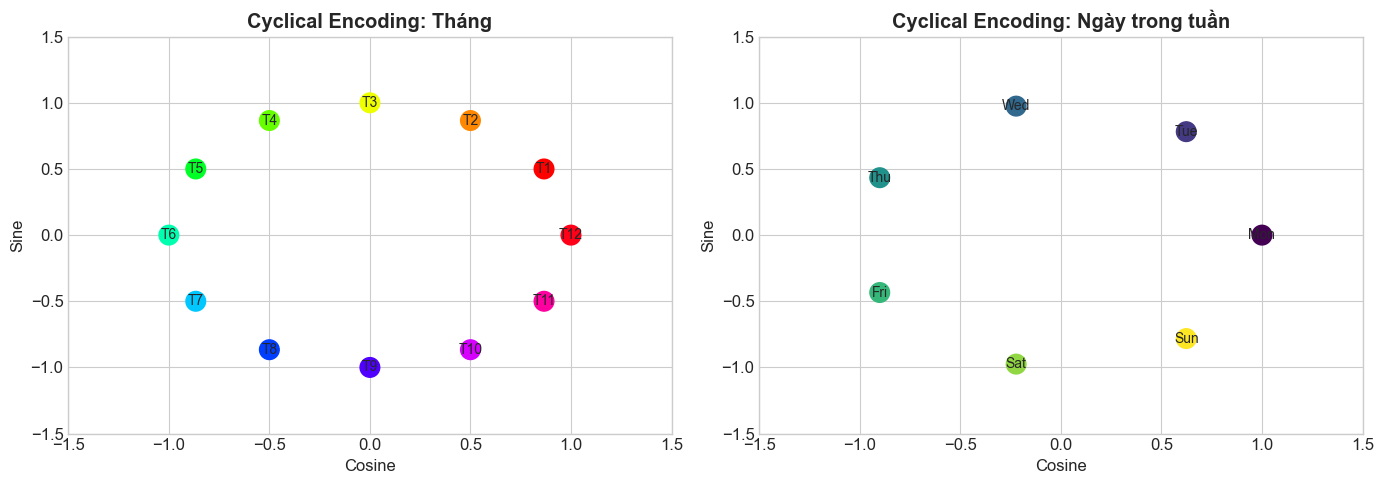

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

months = np.arange(1, 13)
month_sin = np.sin(2 * np.pi * months / 12)
month_cos = np.cos(2 * np.pi * months / 12)
axes[0].scatter(month_cos, month_sin, c=months, cmap='hsv', s=200)
for i, m in enumerate(months):
    axes[0].annotate(f'T{m}', (month_cos[i], month_sin[i]), fontsize=10, ha='center', va='center')
axes[0].set_xlabel('Cosine')
axes[0].set_ylabel('Sine')
axes[0].set_title('Cyclical Encoding: Tháng', fontweight='bold')
axes[0].set_xlim(-1.5, 1.5)
axes[0].set_ylim(-1.5, 1.5)

days = np.arange(0, 7)
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_sin = np.sin(2 * np.pi * days / 7)
day_cos = np.cos(2 * np.pi * days / 7)
axes[1].scatter(day_cos, day_sin, c=days, cmap='viridis', s=200)
for i, d in enumerate(day_names):
    axes[1].annotate(d, (day_cos[i], day_sin[i]), fontsize=10, ha='center', va='center')
axes[1].set_xlabel('Cosine')
axes[1].set_ylabel('Sine')
axes[1].set_title('Cyclical Encoding: Ngày trong tuần', fontweight='bold')
axes[1].set_xlim(-1.5, 1.5)
axes[1].set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

Xem thêm 1 số visualize của các thuộc tính khác dựa trên feature vừa extract

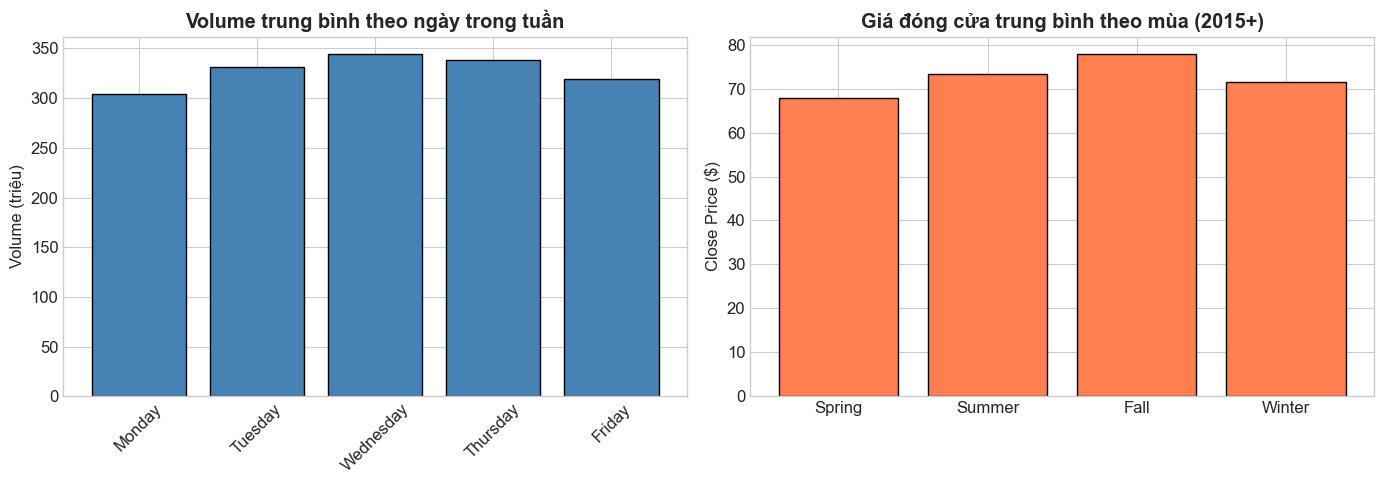

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#vol
vol_by_day = df_features.groupby('DayName')['Volume'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])
axes[0].bar(vol_by_day.index, vol_by_day.values / 1e6, color='steelblue', edgecolor='black')
axes[0].set_title('Volume trung bình theo ngày trong tuần', fontweight='bold')
axes[0].set_ylabel('Volume (triệu)')
axes[0].tick_params(axis='x', rotation=45)

#close
recent_data = df_features[df_features['Year'] >= 2015]
close_by_season = recent_data.groupby('Season')['Close'].mean().reindex(['Spring', 'Summer', 'Fall', 'Winter'])
axes[1].bar(close_by_season.index, close_by_season.values, color='coral', edgecolor='black')
axes[1].set_title('Giá đóng cửa trung bình theo mùa (2015+)', fontweight='bold')
axes[1].set_ylabel('Close Price ($)')

plt.tight_layout()
plt.show()

**Nhận xét:**
- Cyclical encoding giúp model hiểu được tính chu kỳ (tháng 12 gần với tháng 1)
- Volume giao dịch có xu hướng khác nhau theo ngày trong tuần
- Các indicator variables giúp capture hiệu ứng đầu/cuối tháng, cuối quý

---
# d) Resampling Time Series Data

## Lý do cần thiết
- Dữ liệu hàng ngày có thể quá chi tiết cho một số phân tích dài hạn
- Resampling giúp giảm noise và làm nổi bật xu hướng chính
- Upsampling cần thiết khi cần dữ liệu chi tiết hơn (intraday)

Do tính chất của dữ liệu, cần độ chính xác,...
- Làm gì
- Vì sao
- Tác dụng

In [ ]:
df_weekly = df_indexed['Close'].resample('W').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
})

df_monthly = df_indexed['Close'].resample('ME').agg(['mean', 'std', 'min', 'max'])

print("Weekly data shape:", df_weekly.shape)
print("Monthly data shape:", df_monthly.shape)
df_monthly.head(10)

Weekly data shape: (2193, 5)
Monthly data shape: (505, 4)


,mean,std,min,max
Date,,,,
1980-12-31,0.135903,0.017160,0.112723,0.160714
1981-01-31,0.141316,0.006239,0.126116,0.154018
1981-02-28,0.117892,0.006438,0.106027,0.128348
1981-03-31,0.110871,0.007045,0.096540,0.119420
1981-04-30,0.121545,0.006063,0.108259,0.130580
1981-05-31,0.129436,0.009519,0.119978,0.147879
1981-06-30,0.137074,0.007737,0.116071,0.147879
1981-07-31,0.108817,0.004760,0.099330,0.116629
1981-08-31,0.099835,0.010889,0.084263,0.115513


So sánh các tần suất resampling

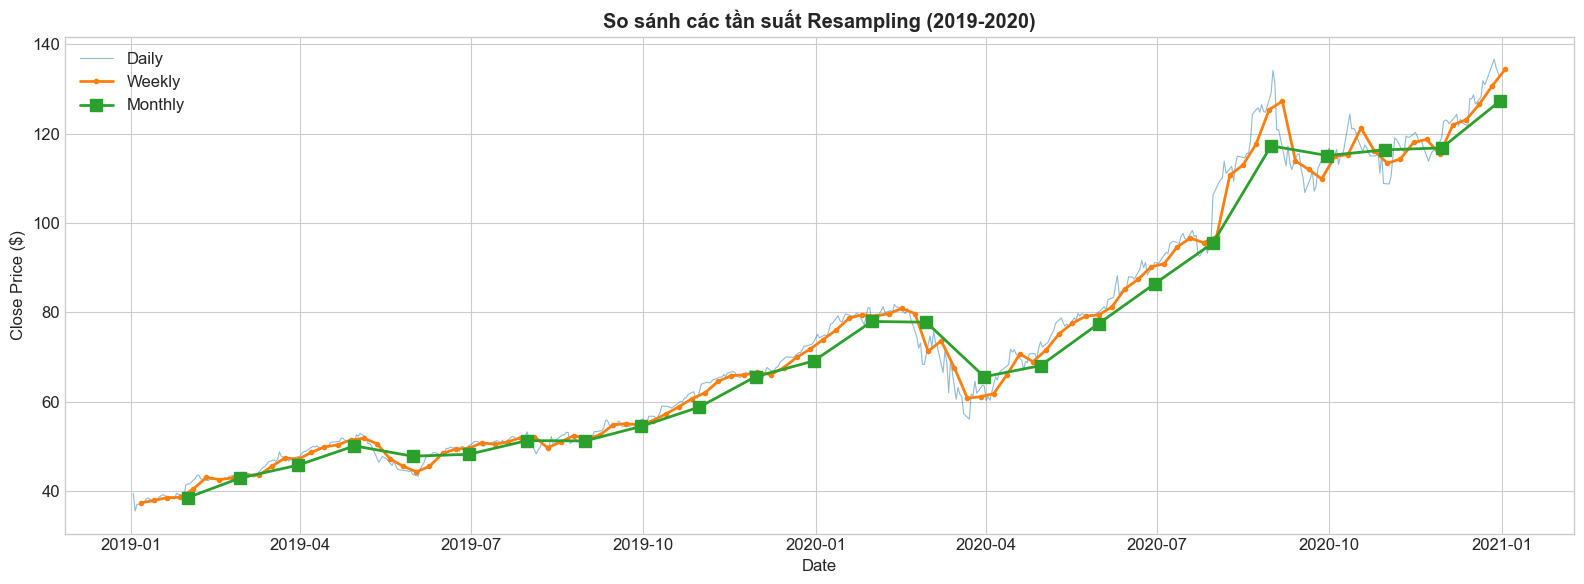

In [ ]:
recent = df_indexed['Close']['2019':'2020']
weekly = recent.resample('W').mean()
monthly = recent.resample('ME').mean()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(recent.index, recent.values, alpha=0.5, label='Daily', linewidth=0.8)
ax.plot(weekly.index, weekly.values, 'o-', label='Weekly', linewidth=2, markersize=3)
ax.plot(monthly.index, monthly.values, 's-', label='Monthly', linewidth=2, markersize=8)

ax.set_title('So sánh các tần suất Resampling (2019-2020)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price ($)')
ax.legend()
plt.tight_layout()
plt.show()

So sánh các aggregation functions

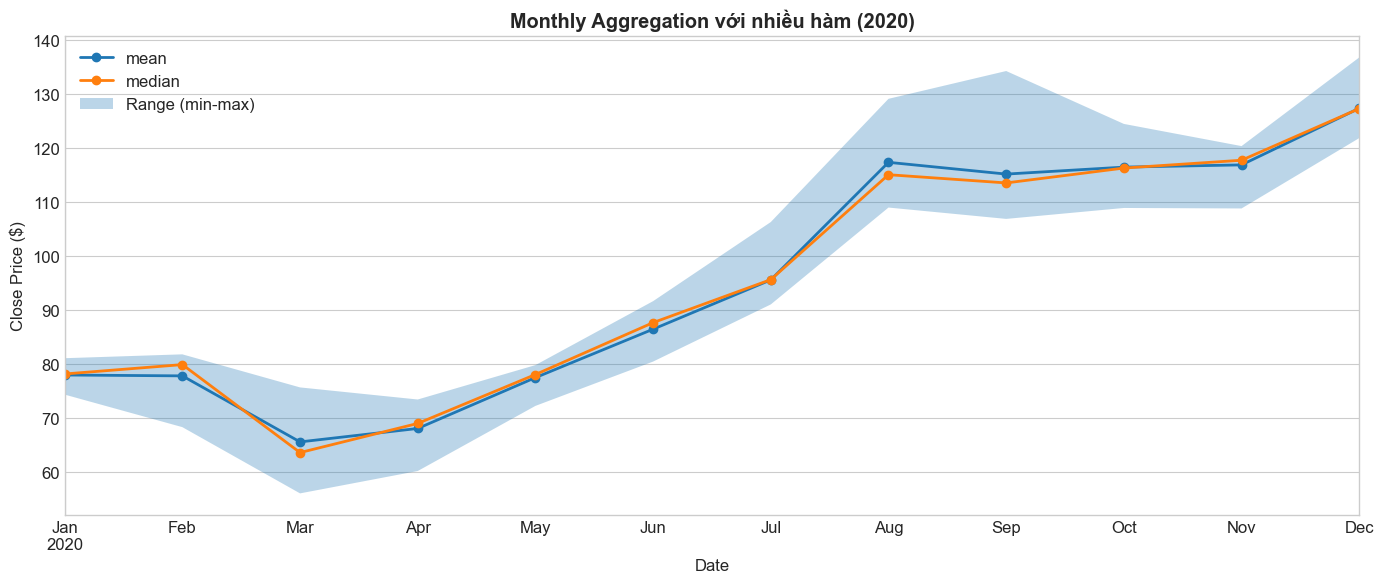

In [ ]:
df_agg = df_indexed['Close']['2020'].resample('ME').agg(['mean', 'median', 'min', 'max', 'std'])

fig, ax = plt.subplots(figsize=(14, 6))
df_agg[['mean', 'median']].plot(ax=ax, marker='o', linewidth=2)
ax.fill_between(df_agg.index, df_agg['min'], df_agg['max'], alpha=0.3, label='Range (min-max)')

ax.set_title('Monthly Aggregation với nhiều hàm (2020)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price ($)')
ax.legend()
plt.tight_layout()
plt.show()

**Nhận xét:**
- Resampling weekly/monthly giúp làm mượt dữ liệu và dễ nhìn xu hướng
- Mean và Median cho kết quả tương tự, Median ít bị ảnh hưởng bởi outliers
- Range (min-max) cho thấy biến động trong từng giai đoạn

---
# e) Lag Features

## Lý do cần thiết
- Lag features giúp model học từ dữ liệu quá khứ để dự đoán tương lai
- Rolling statistics capture xu hướng ngắn hạn và trung hạn
- Autocorrelation giúp xác định lag phù hợp cho modeling

tạo df dành riêng cho feature egineering (ko lấy dữ liệu đc fill)

In [ ]:
df_lag = df_indexed[['Close', 'Volume']].copy()

Tạo lag features

In [ ]:
for lag in [1, 2, 3, 5, 10, 20]:
    df_lag[f'Close_lag_{lag}'] = df_lag['Close'].shift(lag)

print("Lag features:")
df_lag[['Close', 'Close_lag_1', 'Close_lag_2', 'Close_lag_5', 'Close_lag_10']].tail(10)

Lag features:


,Close,Close_lag_1,Close_lag_2,Close_lag_5,Close_lag_10
Date,,,,,
2022-11-29,141.169998,144.220001,148.110001,148.009995,148.279999
2022-11-30,148.029999,141.169998,144.220001,150.179993,150.039993
2022-12-01,148.309998,148.029999,141.169998,151.070007,148.789993
2022-12-02,147.809998,148.309998,148.029999,148.110001,150.720001
2022-12-05,146.630005,147.809998,148.309998,144.220001,151.289993
2022-12-06,142.910004,146.630005,147.809998,141.169998,148.009995
2022-12-07,140.940002,142.910004,146.630005,148.029999,150.179993
2022-12-08,142.649994,140.940002,142.910004,148.309998,151.070007
2022-12-09,142.160004,142.649994,140.940002,147.809998,148.110001


Rolling window statistics

In [ ]:
df_lag['MA_5'] = df_lag['Close'].rolling(window=5).mean()   # Moving Average 5 ngày
df_lag['MA_20'] = df_lag['Close'].rolling(window=20).mean()  # Moving Average 20 ngày
df_lag['MA_50'] = df_lag['Close'].rolling(window=50).mean()  # Moving Average 50 ngày
df_lag['Std_20'] = df_lag['Close'].rolling(window=20).std()  # Rolling Std 20 ngày
df_lag['Min_20'] = df_lag['Close'].rolling(window=20).min()  # Rolling Min
df_lag['Max_20'] = df_lag['Close'].rolling(window=20).max()  # Rolling Max

print("Rolling statistics:")
df_lag[['Close', 'MA_5', 'MA_20', 'MA_50', 'Std_20']].tail(10)

Rolling statistics:


,Close,MA_5,MA_20,MA_50,Std_20
Date,,,,,
2022-11-29,141.169998,146.950000,145.733998,146.135999,5.223129
2022-11-30,148.029999,146.520001,145.602998,145.958599,5.125282
2022-12-01,148.309998,145.967999,145.766998,145.850399,5.158352
2022-12-02,147.809998,145.907999,146.213498,145.751799,4.911422
2022-12-05,146.630005,146.389999,146.625998,145.675799,4.552189
2022-12-06,142.910004,146.738000,146.825498,145.518599,4.275735
2022-12-07,140.940002,145.320001,146.897498,145.302199,4.156344
2022-12-08,142.649994,144.188000,147.286498,145.158399,3.232912
2022-12-09,142.160004,143.058002,147.050999,145.151999,3.430368


Đo chênh lệch bằng Difference features

In [ ]:
df_lag['Close_diff_1'] = df_lag['Close'].diff(1)   # First difference
df_lag['Close_diff_5'] = df_lag['Close'].diff(5)   # 5-day difference
df_lag['Close_pct_change'] = df_lag['Close'].pct_change() * 100  # Percent change

print("Difference features:")
df_lag[['Close', 'Close_diff_1', 'Close_diff_5', 'Close_pct_change']].tail(10)

Difference features:


,Close,Close_diff_1,Close_diff_5,Close_pct_change
Date,,,,
2022-11-29,141.169998,-3.050003,-6.839996,-2.114827
2022-11-30,148.029999,6.860001,-2.149994,4.859390
2022-12-01,148.309998,0.279999,-2.760010,0.189150
2022-12-02,147.809998,-0.500000,-0.300003,-0.337132
2022-12-05,146.630005,-1.179993,2.410004,-0.798317
2022-12-06,142.910004,-3.720001,1.740005,-2.536999
2022-12-07,140.940002,-1.970001,-7.089996,-1.378491
2022-12-08,142.649994,1.709991,-5.660004,1.213276
2022-12-09,142.160004,-0.489990,-5.649994,-0.343491


Phần này chưa mò kĩ

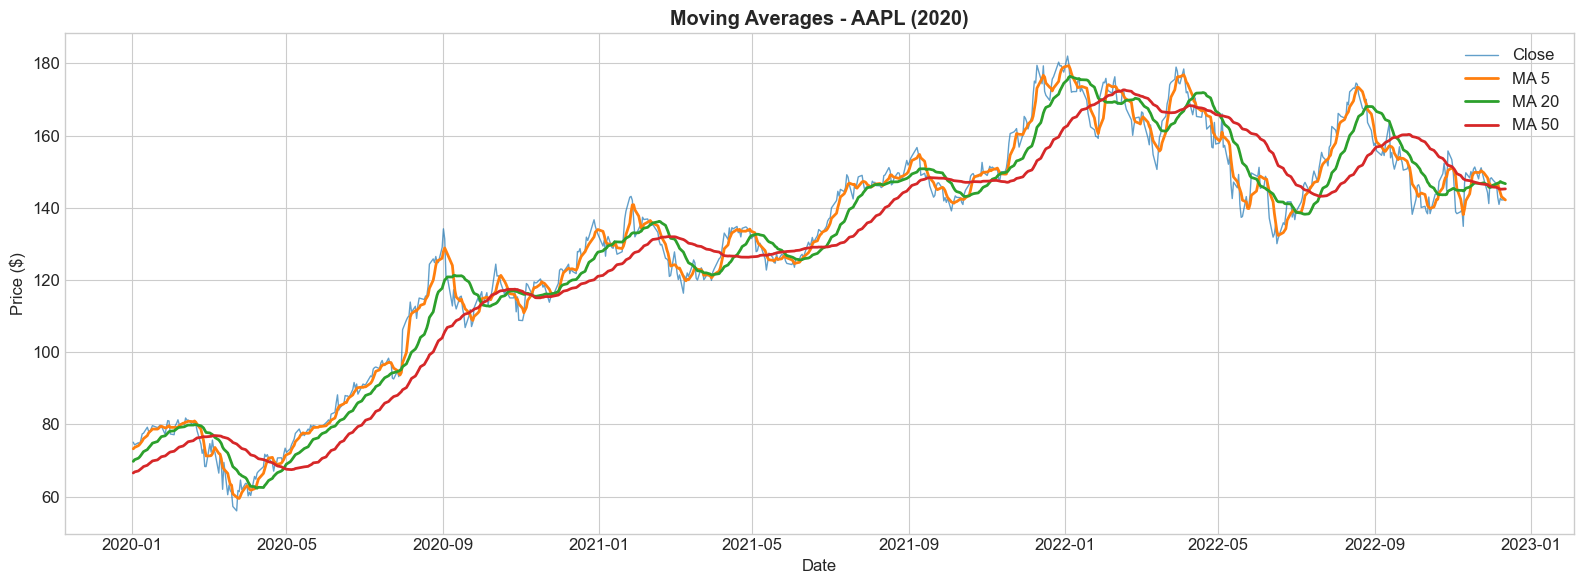

In [ ]:
recent_lag = df_lag['2020':]

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(recent_lag.index, recent_lag['Close'], label='Close', alpha=0.7, linewidth=1)
ax.plot(recent_lag.index, recent_lag['MA_5'], label='MA 5', linewidth=2)
ax.plot(recent_lag.index, recent_lag['MA_20'], label='MA 20', linewidth=2)
ax.plot(recent_lag.index, recent_lag['MA_50'], label='MA 50', linewidth=2)

ax.set_title('Moving Averages - AAPL (2020)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
plt.tight_layout()
plt.show()

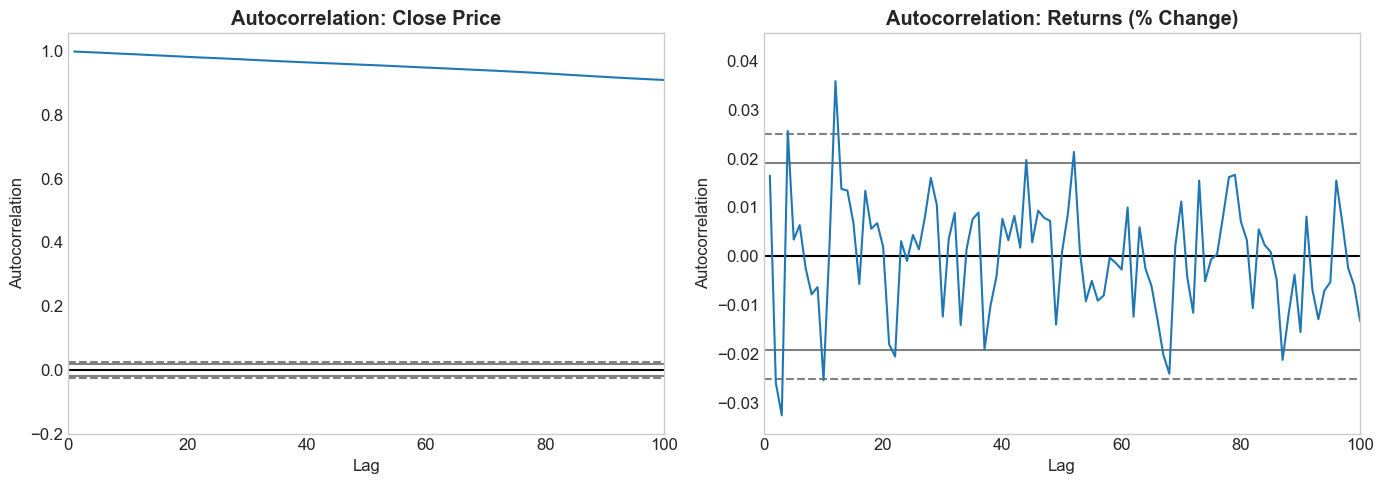

In [27]:
# Autocorrelation analysis
from pandas.plotting import autocorrelation_plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Autocorrelation of Close price
pd.plotting.autocorrelation_plot(df_lag['Close'].dropna(), ax=axes[0])
axes[0].set_title('Autocorrelation: Close Price', fontweight='bold')
axes[0].set_xlim(0, 100)

# Autocorrelation of returns
pd.plotting.autocorrelation_plot(df_lag['Close_pct_change'].dropna(), ax=axes[1])
axes[1].set_title('Autocorrelation: Returns (% Change)', fontweight='bold')
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.show()

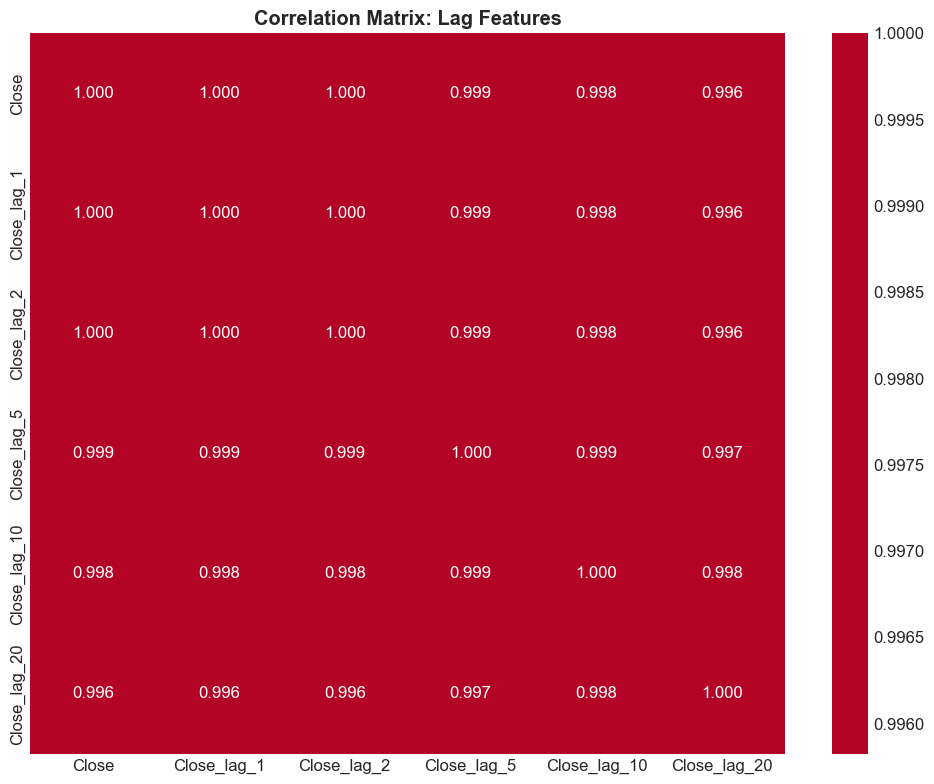

In [28]:
# Correlation matrix của lag features
lag_cols = ['Close', 'Close_lag_1', 'Close_lag_2', 'Close_lag_5', 'Close_lag_10', 'Close_lag_20']
corr_matrix = df_lag[lag_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix: Lag Features', fontweight='bold')
plt.tight_layout()
plt.show()

**Nhận xét:**
- Autocorrelation cao cho thấy giá cổ phiếu có tính liên tục mạnh
- Lag 1 có correlation cao nhất (~0.999) với giá hiện tại
- Returns (pct_change) có autocorrelation thấp hơn, phù hợp với giả thuyết random walk
- Moving averages giúp smooth và identify xu hướng

---
# Tổng kết

## Các kỹ thuật đã áp dụng:

| Kỹ thuật | Mô tả | Kết quả |
|----------|-------|--------|
| **a) Parsing DateTime** | Chuyển đổi string → datetime, trích xuất thành phần | Thành công parse 10,592 records |
| **b) Handling Time Gaps** | Xác định & xử lý ngày thiếu bằng Forward Fill | Xử lý ~4000 ngày thiếu (cuối tuần, lễ) |
| **c) Time-Based Features** | Cyclical encoding, indicators, seasons | Tạo 15+ features mới |
| **d) Resampling** | Downsampling daily → weekly/monthly | Giảm noise, thấy xu hướng rõ hơn |
| **e) Lag Features** | Lag, rolling MA, difference, pct_change | Tạo 20+ lag/rolling features |

## Recommendations:
- Forward Fill phù hợp nhất cho stock data
- Cyclical encoding cần thiết cho features có tính chu kỳ
- MA-20 và MA-50 là indicators phổ biến trong technical analysis
- Returns (pct_change) thường được sử dụng thay vì raw price trong modeling

In [29]:
# Xuất dữ liệu đã xử lý
df_final = df_lag.dropna()
print(f"Shape dữ liệu cuối cùng: {df_final.shape}")
print(f"\nCác cột: {df_final.columns.tolist()}")
df_final.to_csv('../data/temporal/AAPL_preprocessed.csv')
print("\nĐã lưu file: AAPL_preprocessed.csv")

Shape dữ liệu cuối cùng: (10541, 17)

Các cột: ['Close', 'Volume', 'Close_lag_1', 'Close_lag_2', 'Close_lag_3', 'Close_lag_5', 'Close_lag_10', 'Close_lag_20', 'MA_5', 'MA_20', 'MA_50', 'Std_20', 'Min_20', 'Max_20', 'Close_diff_1', 'Close_diff_5', 'Close_pct_change']

Đã lưu file: AAPL_preprocessed.csv
